<a href="https://colab.research.google.com/github/saisathvik-06/BT2024209_polynomial_regression/blob/main/Polynomial_Regression_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files

uploaded = files.upload()   # select all the CSVs

ROLL = "BT2024209"
tr1 = pd.read_csv(f"{ROLL}_train_var1.csv")
te1 = pd.read_csv(f"{ROLL}_test_var1.csv")
feats1 = [f"x{i}" for i in range(1, 7)]
X1, y1 = tr1[feats1].values, tr1["y"].values
print(tr1.shape, te1.shape)

Saving BT2024209_train_var2.csv to BT2024209_train_var2.csv
Saving BT2024209_train_var1.csv to BT2024209_train_var1.csv
Saving BT2024209_test_var2.csv to BT2024209_test_var2.csv
Saving BT2024209_test_var1.csv to BT2024209_test_var1.csv
(1000, 7) (1000, 6)


PHASE 1

1. Analyze at the data (EDA)

count    1000.000
mean        0.870
std         3.166
min        -9.792
25%        -1.088
50%         0.560
75%         2.866
max        12.695
Name: y, dtype: float64
skew: 0.203

Feature correlations:
      x1    x2    x3    x4    x5    x6
x1  1.00  0.53  0.46  0.50  0.02  0.01
x2  0.53  1.00  0.39  0.46  0.02  0.02
x3  0.46  0.39  1.00  0.45  0.00  0.03
x4  0.50  0.46  0.45  1.00  0.03  0.00
x5  0.02  0.02  0.00  0.03  1.00  0.36
x6  0.01  0.02  0.03  0.00  0.36  1.00


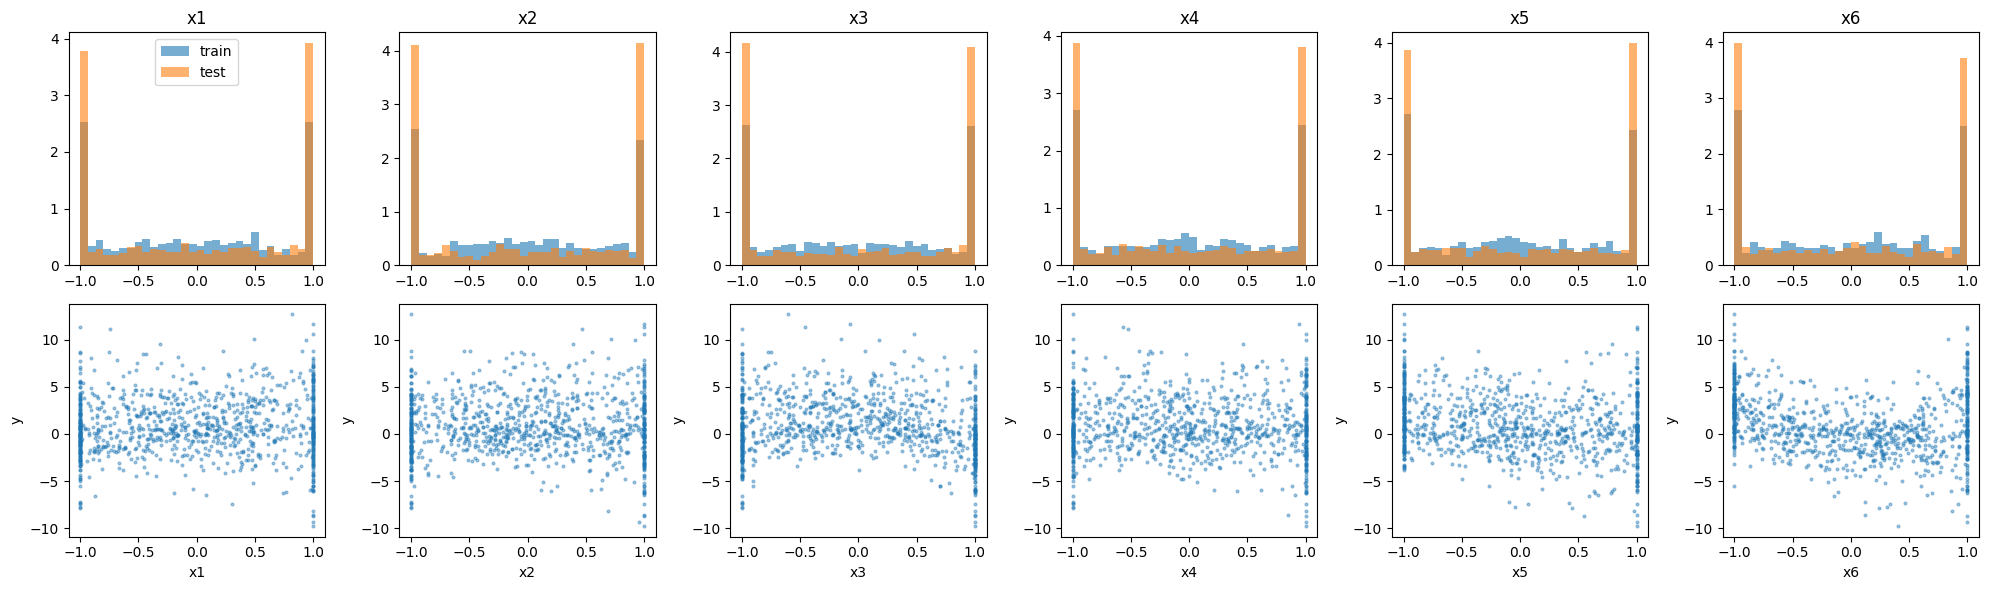

train clipped per row: {0: 0.127, 1: 0.297, 2: 0.305, 3: 0.188, 4: 0.068, 5: 0.015}
test clipped per row: {0: 0.02, 1: 0.091, 2: 0.23, 3: 0.329, 4: 0.235, 5: 0.082, 6: 0.013}
||x|| train quantiles: [1.31 1.75 2.1  2.29]
||x|| test  quantiles: [1.61 2.01 2.28 2.45]


In [2]:
print(tr1["y"].describe().round(3))
print("skew:", round(tr1["y"].skew(), 3))

print("\nFeature correlations:")
print(tr1[feats1].corr().round(2))

# train vs test shift
fig, ax = plt.subplots(2, 6, figsize=(20, 6))
for i, f in enumerate(feats1):
    ax[0, i].hist(tr1[f], bins=30, alpha=.6, label="train", density=True)
    ax[0, i].hist(te1[f], bins=30, alpha=.6, label="test", density=True)
    ax[0, i].set_title(f)
    ax[1, i].scatter(tr1[f], tr1["y"], s=4, alpha=.4)
    ax[1, i].set_xlabel(f); ax[1, i].set_ylabel("y")
ax[0, 0].legend()
plt.tight_layout(); plt.show()

# clipped features per row
for name, d in [("train", tr1), ("test", te1)]:
    k = (d[feats1].abs() == 1).sum(axis=1)
    print(name, "clipped per row:", k.value_counts(normalize=True).sort_index().round(3).to_dict())

# distance from origin
r_tr = np.linalg.norm(tr1[feats1], axis=1); r_te = np.linalg.norm(te1[feats1], axis=1)
print("||x|| train quantiles:", np.quantile(r_tr, [.1, .5, .9, .99]).round(2))
print("||x|| test  quantiles:", np.quantile(r_te, [.1, .5, .9, .99]).round(2))

2. Unregularized degree sweep (degrees 1–6)

var(y) = 10.011
 deg  n_terms  train_mse  mse_random  mse_radius
   1        6      8.928       9.215      18.133
   2       27      2.805       3.061       7.720
   3       83      0.807       1.015       2.138
   4      209      0.378       0.792       1.540
   5      461      0.146       1.550       5.477
   6      923      0.022      79.316     132.070


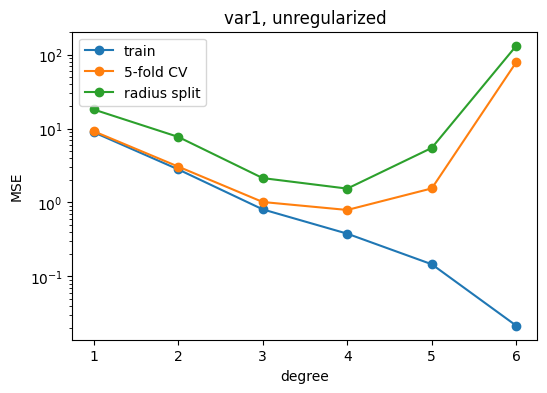

In [3]:
# ---------- validation helpers (reused in later cells) ----------
from sklearn.linear_model import LinearRegression

r = np.linalg.norm(X1, axis=1)
far = r > np.quantile(r, 0.75)      # farthest 25% from origin = "extrapolation" set

def cv_random(make_model, X, y, k=5):
    errs = []
    for a, b in KFold(k, shuffle=True, random_state=0).split(X):
        m = make_model().fit(X[a], y[a])
        errs.append(mean_squared_error(y[b], m.predict(X[b])))
    return np.mean(errs)

def cv_radius(make_model, X, y):
    m = make_model().fit(X[~far], y[~far])
    return mean_squared_error(y[far], m.predict(X[far]))

# ---------- unregularized sweep, degrees 1-6 ----------
def ols_model(deg):
    return lambda: make_pipeline(PolynomialFeatures(deg, include_bias=False),
                                 StandardScaler(), LinearRegression())

rows = []
for deg in range(1, 7):
    mk = ols_model(deg)
    n_terms = PolynomialFeatures(deg, include_bias=False).fit(X1).n_output_features_
    train_mse = mean_squared_error(y1, mk().fit(X1, y1).predict(X1))
    rows.append((deg, n_terms, train_mse, cv_random(mk, X1, y1), cv_radius(mk, X1, y1)))

ols_res = pd.DataFrame(rows, columns=["deg", "n_terms", "train_mse", "mse_random", "mse_radius"])
print("var(y) =", round(y1.var(), 3))
print(ols_res.round(3).to_string(index=False))

plt.figure(figsize=(6, 4))
plt.plot(ols_res.deg, ols_res.train_mse, "o-", label="train")
plt.plot(ols_res.deg, ols_res.mse_random, "o-", label="5-fold CV")
plt.plot(ols_res.deg, ols_res.mse_radius, "o-", label="radius split")
plt.yscale("log"); plt.xlabel("degree"); plt.ylabel("MSE"); plt.legend(); plt.title("var1, unregularized")
plt.show()

3) Ridge grid (degrees 2–10)

In [4]:
alphas = [1e-2, 1e-1, 1, 10, 100, 1e3, 1e4, 1e5]
rows = []
for deg in range(2, 11):
    Xp = PolynomialFeatures(deg, include_bias=False).fit_transform(X1)   # poly features don't depend on the labels, so computing once is safe
    for al in alphas:
        mk = lambda al=al: make_pipeline(StandardScaler(), Ridge(alpha=al))
        rows.append((deg, al, cv_random(mk, Xp, y1), cv_radius(mk, Xp, y1)))
    print("done degree", deg)

ridge_res = pd.DataFrame(rows, columns=["deg", "alpha", "mse_random", "mse_radius"])

print("\n5-fold CV MSE (rows=degree, cols=alpha)")
print(ridge_res.pivot(index="deg", columns="alpha", values="mse_random").round(3).to_string())
print("\nRadius-split MSE (rows=degree, cols=alpha)")
print(ridge_res.pivot(index="deg", columns="alpha", values="mse_radius").round(3).to_string())

print("\nBest by 5-fold CV:    ", ridge_res.loc[ridge_res.mse_random.idxmin()].round(3).to_dict())
print("Best by radius split: ", ridge_res.loc[ridge_res.mse_radius.idxmin()].round(3).to_dict())

done degree 2
done degree 3
done degree 4
done degree 5
done degree 6
done degree 7
done degree 8
done degree 9
done degree 10

5-fold CV MSE (rows=degree, cols=alpha)
alpha  0.01       0.10       1.00       10.00      100.00     1000.00    10000.00   100000.00
deg                                                                                          
2          3.061      3.061      3.060      3.059      3.171      5.103      8.693      9.870
3          1.015      1.015      1.013      1.004      1.184      3.353      7.603      9.654
4          0.792      0.789      0.768      0.726      0.858      1.923      5.592      9.095
5          1.511      1.275      0.792      0.529      0.583      1.379      4.632      8.431
6         16.689      4.225      1.308      0.683      0.652      1.168      3.438      7.495
7          6.667      4.196      1.729      0.842      0.670      1.025      3.044      6.782
8          4.772      3.726      1.975      1.070      0.803      1.045      2.5

4. Lasso grid (degrees 4–8)

In [5]:
import warnings; warnings.filterwarnings("ignore")

lasso_alphas = [0.003, 0.01, 0.03, 0.1, 0.3, 1]
rows = []
for deg in [4, 5, 6, 7, 8]:
    Xp = PolynomialFeatures(deg, include_bias=False).fit_transform(X1)
    for al in lasso_alphas:
        mk = lambda al=al: make_pipeline(StandardScaler(),
                                         Lasso(alpha=al, max_iter=10000, tol=1e-3))
        rows.append((deg, al, cv_random(mk, Xp, y1), cv_radius(mk, Xp, y1)))
    print("done degree", deg)

lasso_res = pd.DataFrame(rows, columns=["deg", "alpha", "mse_random", "mse_radius"])

print("\n5-fold CV MSE (rows=degree, cols=alpha)")
print(lasso_res.pivot(index="deg", columns="alpha", values="mse_random").round(3).to_string())
print("\nRadius-split MSE (rows=degree, cols=alpha)")
print(lasso_res.pivot(index="deg", columns="alpha", values="mse_radius").round(3).to_string())

print("\nBest by 5-fold CV:    ", lasso_res.loc[lasso_res.mse_random.idxmin()].round(3).to_dict())
print("Best by radius split: ", lasso_res.loc[lasso_res.mse_radius.idxmin()].round(3).to_dict())

done degree 4
done degree 5
done degree 6
done degree 7
done degree 8

5-fold CV MSE (rows=degree, cols=alpha)
alpha  0.003  0.010  0.030  0.100  0.300  1.000
deg                                            
4      0.658  0.616  0.689  1.040  2.441  7.728
5      0.363  0.324  0.376  0.765  2.217  7.693
6      0.404  0.339  0.381  0.765  2.206  7.666
7      0.442  0.346  0.380  0.769  2.194  7.666
8      0.464  0.358  0.383  0.776  2.193  7.666

Radius-split MSE (rows=degree, cols=alpha)
alpha  0.003  0.010  0.030  0.100  0.300   1.000
deg                                             
4      1.515  1.557  1.661  2.871  7.400  18.401
5      0.644  0.427  0.505  1.677  6.690  18.401
6      1.425  0.614  0.495  1.651  6.586  18.401
7      2.130  0.990  0.521  1.268  6.405  18.401
8      3.844  1.248  0.528  1.270  6.405  18.401

Best by 5-fold CV:     {'deg': 5.0, 'alpha': 0.01, 'mse_random': 0.324, 'mse_radius': 0.427}
Best by radius split:  {'deg': 5.0, 'alpha': 0.01, 'mse_random': 0.324, 

5. Inspect surviving terms and try relaxed Lasso

In [6]:
from sklearn.base import BaseEstimator, RegressorMixin

# ---- Part A: which terms does Lasso keep? (degree 5, alpha 0.01, full data) ----
poly5 = PolynomialFeatures(5, include_bias=False).fit(X1)
names = poly5.get_feature_names_out(feats1)
X5 = poly5.transform(X1)
Z5 = StandardScaler().fit_transform(X5)
for al in [0.01, 0.03]:
    l = Lasso(alpha=al, max_iter=20000, tol=1e-4).fit(Z5, y1)
    nz = np.flatnonzero(l.coef_)
    print(f"alpha={al}: {len(nz)} nonzero terms out of {X5.shape[1]}")
    top = nz[np.argsort(-np.abs(l.coef_[nz]))][:25]
    print("  top terms by |coef|:", [(names[i], round(l.coef_[i], 2)) for i in top])

# ---- Part B: relaxed lasso (select with Lasso, refit with plain OLS) ----
class RelaxedLasso(BaseEstimator, RegressorMixin):
    def __init__(self, alpha=0.01):
        self.alpha = alpha
    def fit(self, X, y):
        self.sc_ = StandardScaler().fit(X)
        Z = self.sc_.transform(X)
        l = Lasso(alpha=self.alpha, max_iter=10000, tol=1e-3).fit(Z, y)
        self.idx_ = np.flatnonzero(l.coef_)
        self.mean_ = y.mean()
        self.ols_ = LinearRegression().fit(Z[:, self.idx_], y) if len(self.idx_) else None
        return self
    def predict(self, X):
        Z = self.sc_.transform(X)
        return self.ols_.predict(Z[:, self.idx_]) if self.ols_ is not None else np.full(len(Z), self.mean_)

fine_alphas = [0.005, 0.0075, 0.01, 0.015, 0.02, 0.03, 0.05, 0.1]
rows = []
for al in fine_alphas:
    mk_l = lambda al=al: make_pipeline(StandardScaler(), Lasso(alpha=al, max_iter=10000, tol=1e-3))
    mk_r = lambda al=al: RelaxedLasso(al)
    rows.append((al, cv_random(mk_l, X5, y1), cv_radius(mk_l, X5, y1),
                     cv_random(mk_r, X5, y1), cv_radius(mk_r, X5, y1)))
res6 = pd.DataFrame(rows, columns=["alpha", "lasso_random", "lasso_radius",
                                   "relaxed_random", "relaxed_radius"])
print("\nDegree 5: Lasso vs Relaxed Lasso")
print(res6.round(3).to_string(index=False))

alpha=0.01: 122 nonzero terms out of 461
  top terms by |coef|: [('x1 x5', np.float64(-1.25)), ('x2^3 x3', np.float64(-1.02)), ('x3 x6', np.float64(-0.84)), ('x3^3 x6^2', np.float64(-0.7)), ('x6^2', np.float64(0.66)), ('x2 x4 x6', np.float64(-0.63)), ('x2 x6', np.float64(0.6)), ('x2^2 x4^2 x5', np.float64(-0.52)), ('x1^2 x6', np.float64(-0.49)), ('x5^2 x6^3', np.float64(0.47)), ('x6^4', np.float64(0.45)), ('x4^2 x5^2', np.float64(0.43)), ('x1 x3^2 x6^2', np.float64(-0.41)), ('x3^2 x4^2', np.float64(-0.4)), ('x1^2 x3^2 x5', np.float64(-0.39)), ('x1 x5 x6^2', np.float64(-0.33)), ('x1 x3 x6^2', np.float64(0.31)), ('x3^2 x5^2', np.float64(-0.28)), ('x1 x2^2 x4^2', np.float64(0.26)), ('x2 x5^3', np.float64(0.23)), ('x1 x2 x3^2', np.float64(-0.2)), ('x3 x6^4', np.float64(-0.2)), ('x4 x5 x6^3', np.float64(0.19)), ('x2^2 x5^2', np.float64(0.19)), ('x4^3 x5^2', np.float64(-0.18))]
alpha=0.03: 68 nonzero terms out of 461
  top terms by |coef|: [('x1 x5', np.float64(-1.23)), ('x2^3 x3', np.float6

6. Robustness comparison

In [7]:
from sklearn.linear_model import ElasticNet
import warnings; warnings.filterwarnings("ignore")

poly5 = PolynomialFeatures(5, include_bias=False).fit(X1)
X5 = poly5.transform(X1)
rad = np.linalg.norm(X1, axis=1)

def rep_cv(mk, X, y, seeds=(0, 1, 2), k=5):
    scores = []
    for s in seeds:
        errs = []
        for a, b in KFold(k, shuffle=True, random_state=s).split(X):
            m = mk().fit(X[a], y[a])
            errs.append(mean_squared_error(y[b], m.predict(X[b])))
        scores.append(np.mean(errs))
    return np.mean(scores), np.std(scores)

def radius_at(mk, X, y, q):
    far_q = rad > np.quantile(rad, q)
    m = mk().fit(X[~far_q], y[~far_q])
    return mean_squared_error(y[far_q], m.predict(X[far_q]))

def lasso_mk(al):
    return lambda: make_pipeline(StandardScaler(), Lasso(alpha=al, max_iter=10000, tol=1e-3))
def enet_mk(al, l1):
    return lambda: make_pipeline(StandardScaler(), ElasticNet(alpha=al, l1_ratio=l1, max_iter=10000, tol=1e-3))

cands = {
    "lasso a=0.010":   lasso_mk(0.010),
    "lasso a=0.015":   lasso_mk(0.015),
    "lasso a=0.020":   lasso_mk(0.020),
    "relaxed a=0.03":  lambda: RelaxedLasso(0.03),
    "relaxed a=0.05":  lambda: RelaxedLasso(0.05),
    "relaxed a=0.07":  lambda: RelaxedLasso(0.07),
    "enet a=0.02 l1=.5": enet_mk(0.02, 0.5),
    "enet a=0.03 l1=.5": enet_mk(0.03, 0.5),
}

rows = []
for name, mk in cands.items():
    m, s = rep_cv(mk, X5, y1)
    rows.append((name, m, s, *[radius_at(mk, X5, y1, q) for q in (0.6, 0.7, 0.75, 0.8)]))
    print("done", name)

final = pd.DataFrame(rows, columns=["model", "cv_mean", "cv_std", "rad_top40", "rad_top30", "rad_top25", "rad_top20"])
final["rad_avg"] = final[["rad_top40", "rad_top30", "rad_top25", "rad_top20"]].mean(axis=1)
print(final.round(3).to_string(index=False))

done lasso a=0.010
done lasso a=0.015
done lasso a=0.020
done relaxed a=0.03
done relaxed a=0.05
done relaxed a=0.07
done enet a=0.02 l1=.5
done enet a=0.03 l1=.5
            model  cv_mean  cv_std  rad_top40  rad_top30  rad_top25  rad_top20  rad_avg
    lasso a=0.010    0.324   0.008      0.597      0.449      0.427      0.393    0.466
    lasso a=0.015    0.331   0.007      0.497      0.440      0.423      0.374    0.434
    lasso a=0.020    0.344   0.006      0.479      0.463      0.435      0.378    0.439
   relaxed a=0.03    0.333   0.009      0.753      0.638      0.514      0.431    0.584
   relaxed a=0.05    0.350   0.006      0.579      0.541      0.447      0.369    0.484
   relaxed a=0.07    0.367   0.002      0.791      0.587      0.514      0.366    0.564
enet a=0.02 l1=.5    0.341   0.009      0.608      0.501      0.471      0.400    0.495
enet a=0.03 l1=.5    0.358   0.008      0.556      0.523      0.492      0.399    0.492


7. Fit, predict, sanity-check

In [8]:
final_model = make_pipeline(PolynomialFeatures(5, include_bias=False),
                            StandardScaler(),
                            Lasso(alpha=0.015, max_iter=50000, tol=1e-5))
final_model.fit(X1, y1)

# in-sample numbers (for the report)
pred_tr = final_model.predict(X1)
print("train MSE:", round(mean_squared_error(y1, pred_tr), 4), " train R2:", round(r2_score(y1, pred_tr), 4))
print("nonzero terms:", np.count_nonzero(final_model[-1].coef_), "of", final_model[-1].coef_.size)

# test predictions + sanity checks
Xte1 = te1[feats1].values
pred_te = final_model.predict(Xte1)
print("\nshape:", pred_te.shape, " NaNs:", np.isnan(pred_te).sum())
print("train y range:", y1.min().round(2), y1.max().round(2), " mean/std:", y1.mean().round(2), y1.std().round(2))
print("test pred range:", pred_te.min().round(2), pred_te.max().round(2), " mean/std:", pred_te.mean().round(2), pred_te.std().round(2))

# predictions at the most extreme test points (where extrapolation risk is highest)
r_te = np.linalg.norm(Xte1, axis=1)
ext = r_te > np.quantile(np.linalg.norm(X1, axis=1), 0.99)
print("test rows beyond train's 99th pct radius:", ext.sum(), " their pred range:",
      pred_te[ext].min().round(2), pred_te[ext].max().round(2))

out_name = f"{ROLL}_pred_var1.csv"          # ROLL = "BT2024209" from Cell 1
pd.DataFrame({"y": pred_te}).to_csv(out_name, index=False)
files.download(out_name)

train MSE: 0.2591  train R2: 0.9741
nonzero terms: 93 of 461

shape: (1000,)  NaNs: 0
train y range: -9.79 12.69  mean/std: 0.87 3.16
test pred range: -9.98 17.4  mean/std: 1.03 4.01
test rows beyond train's 99th pct radius: 78  their pred range: -9.98 17.4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Safety check

In [9]:
alts = {
    "lasso d5 a=0.010": make_pipeline(PolynomialFeatures(5, include_bias=False), StandardScaler(), Lasso(alpha=0.010, max_iter=20000, tol=1e-4)),
    "lasso d5 a=0.030": make_pipeline(PolynomialFeatures(5, include_bias=False), StandardScaler(), Lasso(alpha=0.030, max_iter=20000, tol=1e-4)),
    "lasso d4 a=0.010": make_pipeline(PolynomialFeatures(4, include_bias=False), StandardScaler(), Lasso(alpha=0.010, max_iter=20000, tol=1e-4)),
    "lasso d6 a=0.030": make_pipeline(PolynomialFeatures(6, include_bias=False), StandardScaler(), Lasso(alpha=0.030, max_iter=20000, tol=1e-4)),
    "ridge d5 a=10":    make_pipeline(PolynomialFeatures(5, include_bias=False), StandardScaler(), Ridge(alpha=10)),
}

rows = []
for name, m in alts.items():
    p = m.fit(X1, y1).predict(Xte1)
    d = p - pred_te
    rows.append((name, np.sqrt((d**2).mean()), np.sqrt((d[ext]**2).mean()), np.abs(d).max(), p.max(), p.min()))
    print("done", name)

cmp = pd.DataFrame(rows, columns=["model", "rms_diff_all", "rms_diff_extreme", "max_abs_diff", "pred_max", "pred_min"])
print(cmp.round(3).to_string(index=False))
print("\nfinal model: pred_max", pred_te.max().round(2), " pred_min", pred_te.min().round(2))
print("test rows with pred > train max:", (pred_te > y1.max()).sum(), " | < train min:", (pred_te < y1.min()).sum())

done lasso d5 a=0.010
done lasso d5 a=0.030
done lasso d4 a=0.010
done lasso d6 a=0.030
done ridge d5 a=10
           model  rms_diff_all  rms_diff_extreme  max_abs_diff  pred_max  pred_min
lasso d5 a=0.010         0.099             0.134         0.572    17.433    -9.998
lasso d5 a=0.030         0.193             0.260         0.967    16.707    -9.995
lasso d4 a=0.010         0.655             1.095         2.747    15.727    -8.920
lasso d6 a=0.030         0.211             0.264         0.986    17.079    -9.906
   ridge d5 a=10         0.730             1.305         4.760    20.450   -10.116

final model: pred_max 17.4  pred_min -9.98
test rows with pred > train max: 5  | < train min: 1


PHASE 2

1. EDA

(1000, 4) (1000, 3)

 count    1000.000
mean        2.192
std         6.690
min       -30.334
25%        -0.740
50%         1.197
75%         4.845
max        39.876
Name: y, dtype: float64
skew: 0.611  kurtosis: 5.523

Feature correlations:
       x1    x2    x3
x1  1.00 -0.02  0.03
x2 -0.02  1.00 -0.03
x3  0.03 -0.03  1.00


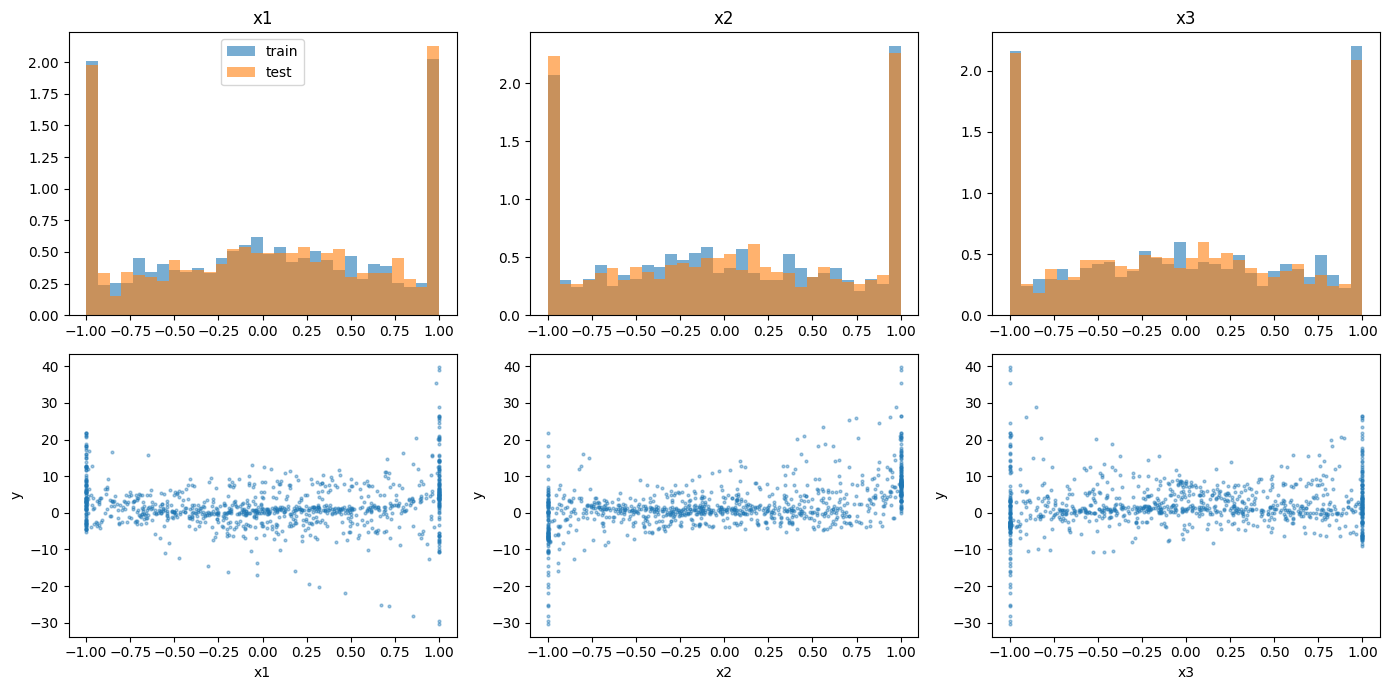

train clipped per row: {0: 0.432, 1: 0.419, 2: 0.133, 3: 0.016}
test clipped per row: {0: 0.436, 1: 0.398, 2: 0.141, 3: 0.025}
||x|| train quantiles: [0.67 1.14 1.5  1.73]
||x|| test  quantiles: [0.67 1.14 1.51 1.73]


In [10]:
# ---------- load var2 ----------
tr2 = pd.read_csv(f"{ROLL}_train_var2.csv")
te2 = pd.read_csv(f"{ROLL}_test_var2.csv")
feats2 = ["x1", "x2", "x3"]
X2, y2 = tr2[feats2].values, tr2["y"].values
Xte2 = te2[feats2].values
print(tr2.shape, te2.shape)

# ---------- generic validation helpers (work for any dataset) ----------
def rep_cv_g(mk, X, y, seeds=(0,), k=5):
    out = []
    for s in seeds:
        errs = []
        for a, b in KFold(k, shuffle=True, random_state=s).split(X):
            errs.append(mean_squared_error(y[b], mk().fit(X[a], y[a]).predict(X[b])))
        out.append(np.mean(errs))
    return np.mean(out)

def radius_g(mk, X, y, q=0.75):
    rr = np.linalg.norm(X, axis=1)
    far_q = rr > np.quantile(rr, q)
    return mean_squared_error(y[far_q], mk().fit(X[~far_q], y[~far_q]).predict(X[far_q]))

# ---------- EDA ----------
print("\n", tr2["y"].describe().round(3))
print("skew:", round(tr2["y"].skew(), 3), " kurtosis:", round(tr2["y"].kurtosis(), 3))
print("\nFeature correlations:\n", tr2[feats2].corr().round(2))

fig, ax = plt.subplots(2, 3, figsize=(14, 7))
for i, f in enumerate(feats2):
    ax[0, i].hist(tr2[f], bins=30, alpha=.6, label="train", density=True)
    ax[0, i].hist(te2[f], bins=30, alpha=.6, label="test", density=True)
    ax[0, i].set_title(f)
    ax[1, i].scatter(tr2[f], tr2["y"], s=4, alpha=.4)
    ax[1, i].set_xlabel(f); ax[1, i].set_ylabel("y")
ax[0, 0].legend(); plt.tight_layout(); plt.show()

for name, d in [("train", tr2), ("test", te2)]:
    k = (d[feats2].abs() == 1).sum(axis=1)
    print(name, "clipped per row:", k.value_counts(normalize=True).sort_index().round(3).to_dict())

r_tr2 = np.linalg.norm(X2, axis=1); r_te2 = np.linalg.norm(Xte2, axis=1)
print("||x|| train quantiles:", np.quantile(r_tr2, [.1, .5, .9, .99]).round(2))
print("||x|| test  quantiles:", np.quantile(r_te2, [.1, .5, .9, .99]).round(2))

2. Unregularized sweep (degrees 1–14, monomial and Legendre bases)

done degree 1
done degree 2
done degree 3
done degree 4
done degree 5
done degree 6
done degree 7
done degree 8
done degree 9
done degree 10
done degree 11
done degree 12
done degree 13
done degree 14

var(y) = 44.71
 deg  n_terms  train_mse_leg  cv_legendre  cv_monomial
   1        3         31.815       32.335       32.335
   2        9         20.026       20.902       20.902
   3       19         10.889       11.999       11.999
   4       34          3.536        4.124        4.124
   5       55          1.236        1.556        1.556
   6       83          0.497        0.683        0.683
   7      119          0.239        0.349        0.349
   8      164          0.177        0.296        0.296
   9      219          0.161        0.309        0.309
  10      285          0.146        0.407        0.407
  11      363          0.128        0.628        0.628
  12      454          0.109        2.539        2.539
  13      559          0.086       30.801       30.801
  14      679

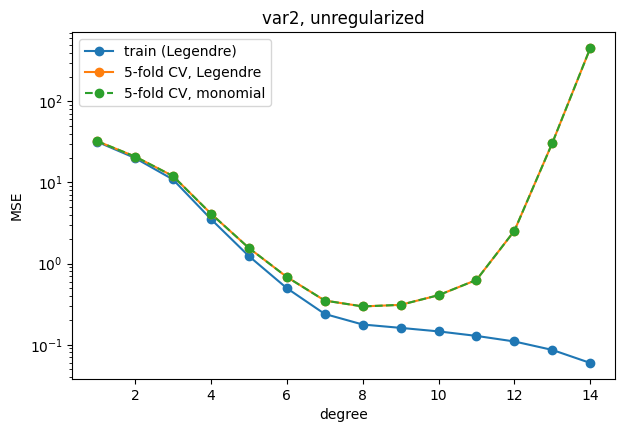

In [11]:
from sklearn.base import TransformerMixin
from numpy.polynomial import legendre as L

class LegendreTotalDegree(BaseEstimator, TransformerMixin):
    """Products P_i(x1) P_j(x2) P_k(x3) with i+j+k <= degree (excluding the constant)."""
    def __init__(self, degree=5):
        self.degree = degree
    def fit(self, X, y=None):
        d = self.degree
        self.combos_ = [(i, j, k) for i in range(d + 1) for j in range(d + 1 - i)
                        for k in range(d + 1 - i - j) if i + j + k > 0]
        return self
    def transform(self, X):
        V = [L.legvander(X[:, c], self.degree) for c in range(3)]
        return np.column_stack([V[0][:, i] * V[1][:, j] * V[2][:, k] for i, j, k in self.combos_])

def mono_ols(d):
    return lambda: make_pipeline(PolynomialFeatures(d, include_bias=False), StandardScaler(), LinearRegression())
def leg_ols(d):
    return lambda: make_pipeline(LegendreTotalDegree(d), LinearRegression())

rows = []
for d in range(1, 15):
    n_terms = LegendreTotalDegree(d).fit(X2).transform(X2[:5]).shape[1]
    tr_mse = mean_squared_error(y2, leg_ols(d)().fit(X2, y2).predict(X2))
    rows.append((d, n_terms, tr_mse,
                 rep_cv_g(leg_ols(d), X2, y2, seeds=(0, 1, 2)),
                 rep_cv_g(mono_ols(d), X2, y2, seeds=(0, 1, 2))))
    print("done degree", d)

res2 = pd.DataFrame(rows, columns=["deg", "n_terms", "train_mse_leg", "cv_legendre", "cv_monomial"])
print("\nvar(y) =", round(y2.var(), 2))
print(res2.round(3).to_string(index=False))

plt.figure(figsize=(7, 4.5))
plt.plot(res2.deg, res2.train_mse_leg, "o-", label="train (Legendre)")
plt.plot(res2.deg, res2.cv_legendre, "o-", label="5-fold CV, Legendre")
plt.plot(res2.deg, res2.cv_monomial, "o--", label="5-fold CV, monomial")
plt.yscale("log"); plt.xlabel("degree"); plt.ylabel("MSE"); plt.legend(); plt.title("var2, unregularized")
plt.show()

3. Ridge grid (degrees 8–20, both bases)

In [12]:
alphas2 = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
degs2 = [8, 10, 12, 14, 16, 18, 20]
rows = []
for d in degs2:
    feats_by_basis = {
        "monomial": PolynomialFeatures(d, include_bias=False).fit_transform(X2),
        "legendre": LegendreTotalDegree(d).fit(X2).transform(X2),
    }
    for basis, Xp in feats_by_basis.items():
        for al in alphas2:
            mk = lambda al=al: make_pipeline(StandardScaler(), Ridge(alpha=al))
            rows.append((basis, d, al, rep_cv_g(mk, Xp, y2, seeds=(0, 1))))
    print("done degree", d, "-", Xp.shape[1], "terms")

ridge2 = pd.DataFrame(rows, columns=["basis", "deg", "alpha", "cv_mse"])
for basis in ["monomial", "legendre"]:
    sub = ridge2[ridge2.basis == basis]
    print(f"\nRidge, {basis}: CV MSE (rows=degree, cols=alpha)")
    print(sub.pivot(index="deg", columns="alpha", values="cv_mse").round(3).to_string())
    print("Best:", sub.loc[sub.cv_mse.idxmin()].to_dict())

done degree 8 - 164 terms
done degree 10 - 285 terms
done degree 12 - 454 terms
done degree 14 - 679 terms
done degree 16 - 968 terms
done degree 18 - 1329 terms
done degree 20 - 1770 terms

Ridge, monomial: CV MSE (rows=degree, cols=alpha)
alpha  0.00001   0.00010   0.00100   0.01000   0.10000   1.00000   10.00000
deg                                                                        
8         0.300     0.300     0.299     0.296     0.295     0.331     0.490
10        0.392     0.384     0.351     0.306     0.278     0.267     0.321
12        1.583     0.765     0.523     0.362     0.290     0.262     0.279
14        5.280     1.909     0.809     0.471     0.318     0.270     0.277
16       14.988     4.751     1.545     0.666     0.362     0.283     0.286
18       33.718    11.589     3.272     1.049     0.431     0.297     0.298
20       79.059    23.176     7.085     1.782     0.548     0.313     0.310
Best: {'basis': 'monomial', 'deg': 12, 'alpha': 1.0, 'cv_mse': 0.2617130577

4. Lasso (two rounds)

In [13]:
import warnings; warnings.filterwarnings("ignore")

lasso_alphas2 = [0.003, 0.01, 0.03, 0.1, 0.3]
degs_l2 = [8, 12, 16, 20]
rows = []
for d in degs_l2:
    Xp = PolynomialFeatures(d, include_bias=False).fit_transform(X2)
    for al in lasso_alphas2:
        mk = lambda al=al: make_pipeline(StandardScaler(), Lasso(alpha=al, max_iter=20000, tol=1e-3))
        rows.append((d, al, rep_cv_g(mk, Xp, y2, seeds=(0,))))
    print("done degree", d, "-", Xp.shape[1], "terms")

lasso2 = pd.DataFrame(rows, columns=["deg", "alpha", "cv_mse"])
print("\nLasso (monomial): CV MSE (rows=degree, cols=alpha)")
print(lasso2.pivot(index="deg", columns="alpha", values="cv_mse").round(3).to_string())
print("Best:", lasso2.loc[lasso2.cv_mse.idxmin()].to_dict())

done degree 8 - 164 terms
done degree 12 - 454 terms
done degree 16 - 968 terms
done degree 20 - 1770 terms

Lasso (monomial): CV MSE (rows=degree, cols=alpha)
alpha  0.003  0.010  0.030  0.100  0.300
deg                                     
8      0.414  0.575  0.975  2.152  5.904
12     0.272  0.370  0.670  1.690  5.605
16     0.271  0.367  0.647  1.614  5.522
20     0.277  0.380  0.658  1.625  5.502
Best: {'deg': 16.0, 'alpha': 0.003, 'cv_mse': 0.2712618302262661}


5. Try with smaller alpha values

In [14]:
import warnings; warnings.filterwarnings("ignore")

lasso_alphas3 = [0.0003, 0.0006, 0.001, 0.002]
rows = []
for d in [12, 16, 20]:
    Xp = PolynomialFeatures(d, include_bias=False).fit_transform(X2)
    for al in lasso_alphas3:
        mk = lambda al=al: make_pipeline(StandardScaler(), Lasso(alpha=al, max_iter=30000, tol=1e-3))
        rows.append((d, al, rep_cv_g(mk, Xp, y2, seeds=(0,))))
    print("done degree", d, "-", Xp.shape[1], "terms")

lasso3 = pd.DataFrame(rows, columns=["deg", "alpha", "cv_mse"])
print("\nLasso (monomial), smaller alphas: CV MSE (rows=degree, cols=alpha)")
print(lasso3.pivot(index="deg", columns="alpha", values="cv_mse").round(3).to_string())
print("Best:", lasso3.loc[lasso3.cv_mse.idxmin()].to_dict())

done degree 12 - 454 terms
done degree 16 - 968 terms
done degree 20 - 1770 terms

Lasso (monomial), smaller alphas: CV MSE (rows=degree, cols=alpha)
alpha  0.0003  0.0006  0.0010  0.0020
deg                                  
12      0.267   0.263   0.259   0.261
16      0.277   0.270   0.267   0.264
20      0.289   0.284   0.278   0.271
Best: {'deg': 12.0, 'alpha': 0.001, 'cv_mse': 0.25942556568889985}


6. Final comparison

In [15]:
from sklearn.base import clone
import warnings; warnings.filterwarnings("ignore")

class AvgModel(BaseEstimator, RegressorMixin):
    def __init__(self, models):
        self.models = models
    def fit(self, X, y):
        self.fitted_ = [clone(m).fit(X, y) for m in self.models]
        return self
    def predict(self, X):
        return np.mean([m.predict(X) for m in self.fitted_], axis=0)

def ridge_pipe(d, al):
    return make_pipeline(PolynomialFeatures(d, include_bias=False), StandardScaler(), Ridge(alpha=al))
def lasso_pipe(d, al):
    return make_pipeline(PolynomialFeatures(d, include_bias=False), StandardScaler(),
                         Lasso(alpha=al, max_iter=30000, tol=1e-3))

cands2 = {
    "ridge d12 a=0.5":  lambda: ridge_pipe(12, 0.5),
    "ridge d12 a=1":    lambda: ridge_pipe(12, 1),
    "ridge d12 a=2":    lambda: ridge_pipe(12, 2),
    "ridge d10 a=1":    lambda: ridge_pipe(10, 1),
    "ridge d14 a=1":    lambda: ridge_pipe(14, 1),
    "lasso d12 a=.001": lambda: lasso_pipe(12, 0.001),
    "lasso d12 a=.002": lambda: lasso_pipe(12, 0.002),
    "avg ridge+lasso":  lambda: AvgModel([ridge_pipe(12, 1), lasso_pipe(12, 0.001)]),
}

rows = []
for name, mk in cands2.items():
    per_seed = [rep_cv_g(mk, X2, y2, seeds=(s,)) for s in (0, 1, 2)]
    rows.append((name, np.mean(per_seed), np.std(per_seed)))
    print("done", name)
cmp2 = pd.DataFrame(rows, columns=["model", "cv_mean", "cv_std"])
print(cmp2.round(4).to_string(index=False))

# out-of-fold error: edge rows (any |x|=1) vs interior rows, for ridge d12 a=1
oof = np.zeros(len(y2))
for a, b in KFold(5, shuffle=True, random_state=0).split(X2):
    oof[b] = ridge_pipe(12, 1).fit(X2[a], y2[a]).predict(X2[b])
edge = (np.abs(X2) == 1).any(axis=1)
print("\nOOF MSE edge rows   :", round(mean_squared_error(y2[edge], oof[edge]), 3), f"({edge.mean():.0%} of rows)")
print("OOF MSE interior rows:", round(mean_squared_error(y2[~edge], oof[~edge]), 3))

done ridge d12 a=0.5
done ridge d12 a=1
done ridge d12 a=2
done ridge d10 a=1
done ridge d14 a=1
done lasso d12 a=.001
done lasso d12 a=.002
done avg ridge+lasso
           model  cv_mean  cv_std
 ridge d12 a=0.5   0.2697  0.0041
   ridge d12 a=1   0.2620  0.0014
   ridge d12 a=2   0.2575  0.0024
   ridge d10 a=1   0.2619  0.0069
   ridge d14 a=1   0.2737  0.0056
lasso d12 a=.001   0.2576  0.0038
lasso d12 a=.002   0.2589  0.0030
 avg ridge+lasso   0.2571  0.0018

OOF MSE edge rows   : 0.277 (57% of rows)
OOF MSE interior rows: 0.246


7. Checking with elastic nets

In [16]:
from sklearn.linear_model import ElasticNet
import warnings; warnings.filterwarnings("ignore")

Xp12 = PolynomialFeatures(12, include_bias=False).fit_transform(X2)   # label-independent, safe to compute once
en_alphas = [0.0005, 0.001, 0.002, 0.004, 0.008]
en_ratios = [0.2, 0.5, 0.8]

rows = []
for l1 in en_ratios:
    for al in en_alphas:
        mk = lambda al=al, l1=l1: make_pipeline(StandardScaler(),
                 ElasticNet(alpha=al, l1_ratio=l1, max_iter=30000, tol=1e-3))
        per_seed = [rep_cv_g(mk, Xp12, y2, seeds=(s,)) for s in (0, 1, 2)]
        rows.append((l1, al, np.mean(per_seed), np.std(per_seed)))
    print("done l1_ratio", l1)

en2 = pd.DataFrame(rows, columns=["l1_ratio", "alpha", "cv_mean", "cv_std"])
print("\nElasticNet, degree 12: CV MSE (rows=l1_ratio, cols=alpha)")
print(en2.pivot(index="l1_ratio", columns="alpha", values="cv_mean").round(4).to_string())
print("Best:", en2.loc[en2.cv_mean.idxmin()].round(4).to_dict())
print("Reference (Cell 15): ridge d12 a=2 -> 0.2575 | lasso d12 a=.001 -> 0.2576")

done l1_ratio 0.2
done l1_ratio 0.5
done l1_ratio 0.8

ElasticNet, degree 12: CV MSE (rows=l1_ratio, cols=alpha)
alpha     0.0005  0.0010  0.0020  0.0040  0.0080
l1_ratio                                        
0.2       0.2700  0.2625  0.2571  0.2572  0.2719
0.5       0.2661  0.2604  0.2570  0.2620  0.2907
0.8       0.2638  0.2586  0.2579  0.2718  0.3104
Best: {'l1_ratio': 0.5, 'alpha': 0.002, 'cv_mean': 0.257, 'cv_std': 0.0038}
Reference (Cell 15): ridge d12 a=2 -> 0.2575 | lasso d12 a=.001 -> 0.2576


8. Fit and sanity-check

In [17]:
final2 = ridge_pipe(12, 2).fit(X2, y2)
pred2 = final2.predict(Xte2)

pred_tr2 = final2.predict(X2)
print("train MSE:", round(mean_squared_error(y2, pred_tr2), 4), " train R2:", round(r2_score(y2, pred_tr2), 4))
print("shape:", pred2.shape, " NaNs:", np.isnan(pred2).sum())
print("train y range:", y2.min().round(2), y2.max().round(2), " mean/std:", y2.mean().round(2), y2.std().round(2))
print("test pred range:", pred2.min().round(2), pred2.max().round(2), " mean/std:", pred2.mean().round(2), pred2.std().round(2))
print("test rows with pred > train max:", (pred2 > y2.max()).sum(), " | < train min:", (pred2 < y2.min()).sum())

# stability check: how much do other near-tied models disagree with the final one?
edge_te = (np.abs(Xte2) == 1).any(axis=1)
alts2 = {
    "ridge d12 a=1":    ridge_pipe(12, 1),
    "ridge d10 a=2":    ridge_pipe(10, 2),
    "ridge d14 a=2":    ridge_pipe(14, 2),
    "lasso d12 a=.001": lasso_pipe(12, 0.001),
}
rows = []
for name, m in alts2.items():
    p = m.fit(X2, y2).predict(Xte2)
    d = p - pred2
    rows.append((name, np.sqrt((d**2).mean()), np.sqrt((d[edge_te]**2).mean()), np.abs(d).max()))
print(pd.DataFrame(rows, columns=["model", "rms_diff_all", "rms_diff_edge", "max_abs_diff"]).round(3).to_string(index=False))

out_name = f"{ROLL}_pred_var2.csv"
pd.DataFrame({"y": pred2}).to_csv(out_name, index=False)
files.download(out_name)

train MSE: 0.1716  train R2: 0.9962
shape: (1000,)  NaNs: 0
train y range: -30.33 39.88  mean/std: 2.19 6.69
test pred range: -29.87 39.18  mean/std: 2.41 7.18
test rows with pred > train max: 0  | < train min: 0
           model  rms_diff_all  rms_diff_edge  max_abs_diff
   ridge d12 a=1         0.036          0.036         0.170
   ridge d10 a=2         0.091          0.110         0.477
   ridge d14 a=2         0.055          0.066         0.346
lasso d12 a=.001         0.076          0.088         0.370


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Final verification of the files output format

In [18]:
import os
for v, n_in in [("var1", len(te1)), ("var2", len(te2))]:
    fn = f"{ROLL}_pred_{v}.csv"
    if not os.path.exists(fn):
        print(fn, "-> MISSING in this Colab session (re-run the save step)"); continue
    d = pd.read_csv(fn)
    print(fn, "| shape:", d.shape, "| columns:", list(d.columns), "| NaNs:", int(d.isna().sum().sum()),
          "| rows match test file:", len(d) == n_in)

BT2024209_pred_var1.csv | shape: (1000, 1) | columns: ['y'] | NaNs: 0 | rows match test file: True
BT2024209_pred_var2.csv | shape: (1000, 1) | columns: ['y'] | NaNs: 0 | rows match test file: True
